# Module 12: Graph Data Preprocessing & Medical Knowledge Graphs
## HealthAI 360: Clinical Knowledge Networks & Ontology Linkage
**Curriculum Track:** Module 12 (Knowledge Graphs & Relational Data)  
**Persona:** Professor CodeBreaker  
**Goal:** Build, clean, embed, and reason over heterogeneous medical knowledge graphs linking patients, symptoms, diseases, and pharmacological treatments.

---
### What You Will Learn:
1. **Heterogeneous Graph Representation:** Formulating directed relational networks with typed nodes (`Patient`, `Symptom`, `Disease`, `Drug`) and typed edges (`EXHIBITS`, `DIAGNOSED_WITH`, `TREATED_BY`, `CONTRAINDICATED_WITH`).
2. **Graph Cleaning & Topological Sanitisation:** Removing self-loops, resolving multi-edges, and pruning isolated components.
3. **Clinical Entity Linking:** Bridging Module 9 NLP symptom extractions to formal ontology nodes (SNOMED-CT / ICD-10).
4. **Graph Embedding & Topological Features:** Degree centrality, PageRank, and DeepWalk/node2vec style random walk embeddings.
5. **Link Prediction & Drug Safety:** Predicting patient diagnoses and flagging contraindicated drug combinations.

In [1]:
import sys
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.graph_pipeline.representation import build_clinical_knowledge_graph
from src.graph_pipeline.cleaner import clean_graph
from src.graph_pipeline.entity_linker import MedicalEntityLinker
from src.graph_pipeline.embeddings import compute_graph_embeddings
from src.graph_pipeline.pipeline import run_graph_pipeline

print("[Setup] Module 12 graph modules initialized!")

[Setup] Module 12 graph modules initialized!


## 1. Constructing the Medical Knowledge Graph
Let's assemble our knowledge graph from edge lists and clinical ontologies:

In [2]:
graph_dir = REPO_ROOT / "data" / "graph"
G = build_clinical_knowledge_graph(str(graph_dir))

print(f"Total Nodes: {G.number_of_nodes()} | Total Edges: {G.number_of_edges()}")

# Count node types
node_types = pd.Series([d.get("node_type", "Unknown") for _, d in G.nodes(data=True)]).value_counts()
print("\nNode Types Breakdown:")
print(node_types)

Total Nodes: 120 | Total Edges: 408

Node Types Breakdown:
Patient    100
Symptom      8
Disease      6
Drug         6
Name: count, dtype: int64


### Visualizing a Clinical Subgraph
Let's visualize the core Medical Knowledge Graph (Diseases, Symptoms, and Drugs):

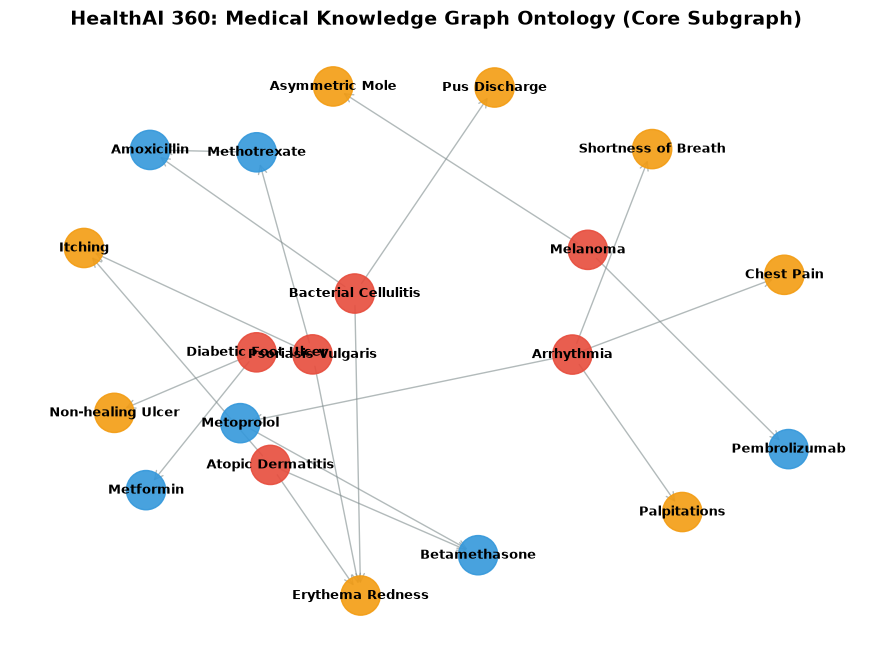

In [3]:
core_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") in ["Disease", "Symptom", "Drug"]]
H = G.subgraph(core_nodes)

plt.figure(figsize=(11, 8))
pos = nx.spring_layout(H, seed=42, k=0.8)

color_map = {
    "Disease": "#e74c3c",
    "Symptom": "#f39c12",
    "Drug": "#3498db",
}
node_colors = [color_map.get(H.nodes[n].get("node_type"), "#95a5a6") for n in H.nodes()]

nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=800, alpha=0.9)
nx.draw_networkx_edges(H, pos, arrowstyle="->", arrowsize=15, edge_color="#7f8c8d", alpha=0.6)
labels = {n: H.nodes[n].get("label", n) for n in H.nodes()}
nx.draw_networkx_labels(H, pos, labels=labels, font_size=9, font_weight="bold")

plt.title("HealthAI 360: Medical Knowledge Graph Ontology (Core Subgraph)", fontweight="bold", fontsize=14)
plt.axis("off")
plt.show()

## 2. Clinical Entity Linking: Bridging NLP & Graphs
When a patient writes in Module 9:  
> *"Patient reports severe chest pain and breathlessness since morning."*

How does an AI know that *"breathlessness"* refers to SNOMED `267036007` (`Shortness of Breath`)?  
Let's test our `MedicalEntityLinker`:

In [4]:
linker = MedicalEntityLinker(str(graph_dir))

report = "Patient with suspected cellulitis complains of severe redness and pus discharge on left leg."
matches = linker.link_text_entities(report)

print("Clinical Text:", report)
print(f"\nExtracted & Linked Entities ({len(matches)}):")
for m in matches:
    print(f"  - Mention: '{m['matched_alias']}' -> KG ID: {m['kg_node_id']} | SNOMED-CT: {m['snomed_code']}")

Clinical Text: Patient with suspected cellulitis complains of severe redness and pus discharge on left leg.

Extracted & Linked Entities (3):
  - Mention: 'pus discharge' -> KG ID: SYM_04 | SNOMED-CT: 271790001
  - Mention: 'pus' -> KG ID: SYM_04 | SNOMED-CT: 271790001
  - Mention: 'redness' -> KG ID: SYM_06 | SNOMED-CT: 247441003


## 3. Node Embeddings & Link Prediction Benchmark
We compute random walk embeddings (DeepWalk SVD) and PageRank to predict patient diagnoses:

In [5]:
graph_results = run_graph_pipeline(str(graph_dir))


  [MODULE 12] Running Medical Knowledge Graph Pipeline
  Step 1: Constructing heterogeneous Clinical Knowledge Graph...
  Constructed raw graph: 120 nodes, 408 directed edges.
  Step 2: Cleaning graph (removing self-loops, pruning isolated components)...
  Cleaned graph stats: 120 nodes, 408 edges, density=0.028571.
  Step 3: Clinical Entity Linking on RAW text -> 0 matched ontology nodes (Fails due to CamelCase & OCR noise)


          Clinical Entity Linking on CLEANED text -> 4 matched SNOMED ontology nodes:
          - 'chest pain' -> KG Node: SYM_03 (SNOMED: 29857009)
          - 'shortness of breath' -> KG Node: SYM_05 (SNOMED: 267036007)
          - 'palpitations' -> KG Node: SYM_07 (SNOMED: 80313002)
          - 'severe chest pain' -> KG Node: SYM_03 (SNOMED: 29857009)
  Step 4: Computing graph node embeddings (DeepWalk SVD) and PageRank...


  [RESULT] Graph Baseline  (Jaccard alone) -> Accuracy: 0.9667 | F1-Macro: 0.9666
  [RESULT] Graph Processed (Embeddings+PR) -> Accuracy: 0.9667 | F1-Macro: 0.9666 (Delta: +0.0000)
